# TASK 3: Data Visualization

In [14]:
#Goal: Transform raw data into charts and dashboards that tell a data story.
#Tools: `matplotlib`, `seaborn`

In [21]:
# Import required visualization and data libraries
# matplotlib.pyplot : core plotting library
# matplotlib.patches : used for custom legends or shapes (optional use)
# matplotlib.gridspec : helps create complex subplot layouts
# seaborn : high-level statistical visualization (optional, styling support)
# numpy : numerical operations
# pandas : data loading and manipulation

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd

# Load the dataset from CSV file into a DataFrame
df = pd.read_csv("scraped_books.csv")

# Update Matplotlib global style settings
# This section customizes the entire visual theme (dark mode)
plt.rcParams.update({

    # Figure and axes background colors
    'figure.facecolor': '#0d0d1a',
    'axes.facecolor': '#141428',

    # Axis edge and label colors
    'axes.edgecolor': '#2a2a50',
    'axes.labelcolor': '#c8c8e8',

    # Text and tick colors
    'text.color': '#c8c8e8',
    'xtick.color': '#9999bb',
    'ytick.color': '#9999bb',

    # Grid appearance
    'grid.color': '#2a2a50',
    'grid.linestyle': '--',
    'grid.alpha': 0.6,

    # Font settings
    'font.family': 'monospace',

    # Remove top and right axis spines for cleaner look
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Define a custom color palette for charts
# These colors will be reused across multiple visualizations
PALETTE = [
    '#7c6bf5',  # Purple
    '#ff6584',  # Pink
    '#43e0d0',  # Cyan
    '#ffd166',  # Yellow
    '#06d6a0',  # Green
    '#ef476f'   # Red
]

# Inform the user that the visualization theme is ready
print("Theme ready. Generating charts...")

Theme ready. Generating charts...


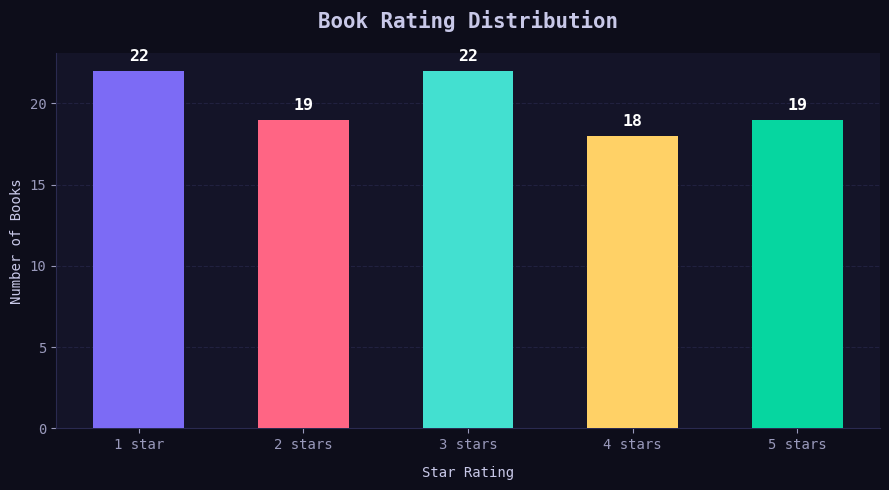

Chart 1 saved: chart1_rating_distribution.png


In [22]:
# CHART 1 : Book Rating Distribution

# Create a figure and axis object with specified size
fig, ax = plt.subplots(figsize=(9, 5))

# Count the number of books for each rating and sort by rating value
rating_counts = df['Rating'].value_counts().sort_index()

# Create readable labels like "1 star", "2 stars", etc.
labels = [
    str(r) + ' star' + ('s' if r > 1 else '')
    for r in rating_counts.index
]

# Plot a bar chart using the custom color palette
bars = ax.bar(
    labels,
    rating_counts.values,
    color=PALETTE[:5],      # Use first 5 colors from palette
    edgecolor='none',
    width=0.55,
    zorder=3
)

# Add value labels on top of each bar
for bar, val in zip(bars, rating_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # Center text horizontally
        bar.get_height() + 0.4,              # Slightly above bar
        str(val),
        ha='center',
        va='bottom',
        fontsize=12,
        color='white',
        fontweight='bold'
    )

# Set chart title with styling
ax.set_title(
    "Book Rating Distribution",
    fontsize=15,
    fontweight='bold',
    pad=18
)

# Set axis labels
ax.set_xlabel("Star Rating", labelpad=10)
ax.set_ylabel("Number of Books")

# Enable grid lines only on Y-axis for readability
ax.grid(axis='y', zorder=0)

# Ensure grid lines appear behind bars
ax.set_axisbelow(True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the chart as a PNG file
plt.savefig(
    "chart1_rating_distribution.png",
    dpi=150,
    bbox_inches='tight'
)

# Display the chart
plt.show()

# Confirm chart file creation
print("Chart 1 saved: chart1_rating_distribution.png")

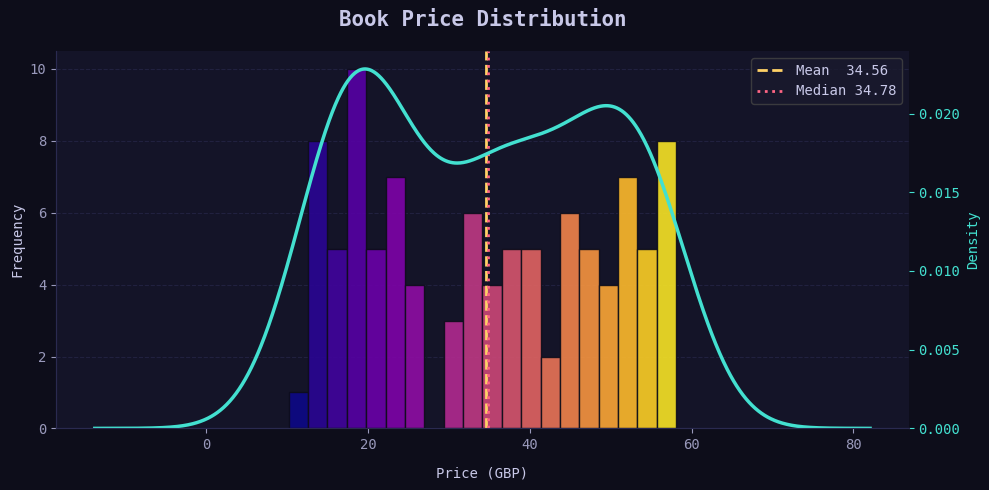

Chart 2 saved: chart2_price_distribution.png


In [23]:
# CHART 2 : Price Distribution with KDE

# Create a figure and axis object with specified size
fig, ax = plt.subplots(figsize=(10, 5))

# Plot histogram of book prices
# bins=20 divides the price range into 20 intervals
n_bins, bins, patches = ax.hist(
    df['Price_GBP'],
    bins=20,
    edgecolor='#0d0d1a',
    alpha=0.9,
    zorder=3
)

# Apply a gradient color effect to histogram bars using plasma colormap
for i, patch in enumerate(patches):
    patch.set_facecolor(plt.cm.plasma(i / len(patches)))

# Create a secondary y-axis for KDE (density curve)
ax2 = ax.twinx()

# Plot Kernel Density Estimation (KDE) curve for price distribution
df['Price_GBP'].plot.kde(
    ax=ax2,
    color='#43e0d0',
    linewidth=2.5
)

# Label and style the secondary y-axis
ax2.set_ylabel("Density", color='#43e0d0')
ax2.tick_params(axis='y', colors='#43e0d0')
ax2.set_ylim(0)

# Draw a vertical line showing the mean price
ax.axvline(
    df['Price_GBP'].mean(),
    color='#ffd166',
    lw=2,
    ls='--',
    zorder=5,
    label=f"Mean  {df['Price_GBP'].mean():.2f}"
)

# Draw a vertical line showing the median price
ax.axvline(
    df['Price_GBP'].median(),
    color='#ff6584',
    lw=2,
    ls=':',
    zorder=5,
    label=f"Median {df['Price_GBP'].median():.2f}"
)

# Set chart title with formatting
ax.set_title(
    "Book Price Distribution",
    fontsize=15,
    fontweight='bold',
    pad=18
)

# Set axis labels
ax.set_xlabel("Price (GBP)", labelpad=10)
ax.set_ylabel("Frequency")

# Add legend for mean and median lines
ax.legend(
    facecolor='#1a1a2e',
    edgecolor='#444',
    fontsize=10
)

# Enable grid lines on Y-axis
ax.grid(axis='y', zorder=0)

# Adjust layout to avoid overlap
plt.tight_layout()

# Save the chart as a PNG image
plt.savefig(
    "chart2_price_distribution.png",
    dpi=150,
    bbox_inches='tight'
)

# Display the chart
plt.show()

# Confirm chart file creation
print("Chart 2 saved: chart2_price_distribution.png")

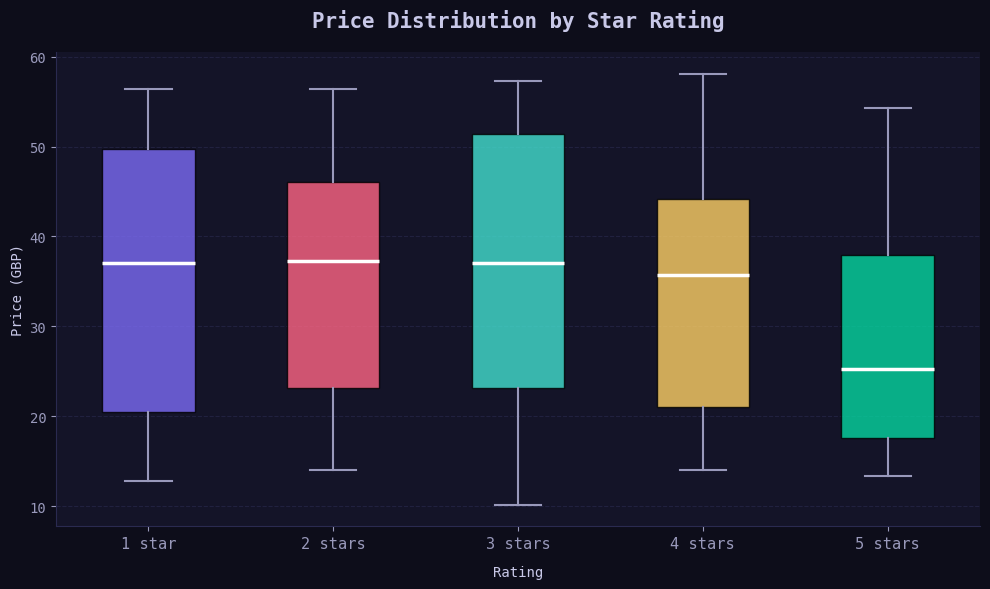

Chart 3 saved: chart3_price_by_rating.png


In [24]:
# CHART 3 : Box Plot - Price by Rating

# Create a figure and axis object with specified size
fig, ax = plt.subplots(figsize=(10, 6))

# Group book prices based on star ratings (1 to 5)
# Each list element contains prices for one rating group
groups = [
    df[df['Rating'] == r]['Price_GBP'].values
    for r in range(1, 6)
]

# Create box plot with customized styling
bp = ax.boxplot(
    groups,
    patch_artist=True,   # Allows box colors to be filled

    # Customize median line appearance
    medianprops=dict(color='white', linewidth=2.5),

    # Customize whiskers and caps
    whiskerprops=dict(color='#9999bb', linewidth=1.5),
    capprops=dict(color='#9999bb', linewidth=1.5),

    # Customize outlier (flier) points
    flierprops=dict(
        marker='o',
        markersize=4,
        alpha=0.5,
        markerfacecolor='white',
        markeredgecolor='none'
    )
)

# Apply custom colors to each box using the palette
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

# Set x-axis labels with proper star formatting
ax.set_xticklabels(
    [f'{r} star' + ('s' if r > 1 else '') for r in range(1, 6)],
    fontsize=11
)

# Set chart title
ax.set_title(
    "Price Distribution by Star Rating",
    fontsize=15,
    fontweight='bold',
    pad=18
)

# Set axis labels
ax.set_xlabel("Rating", labelpad=10)
ax.set_ylabel("Price (GBP)")

# Enable grid lines on Y-axis for better readability
ax.grid(axis='y')

# Adjust layout to prevent label overlap
plt.tight_layout()

# Save the chart as a PNG image
plt.savefig(
    "chart3_price_by_rating.png",
    dpi=150,
    bbox_inches='tight'
)

# Display the chart
plt.show()

# Confirm chart file creation
print("Chart 3 saved: chart3_price_by_rating.png")

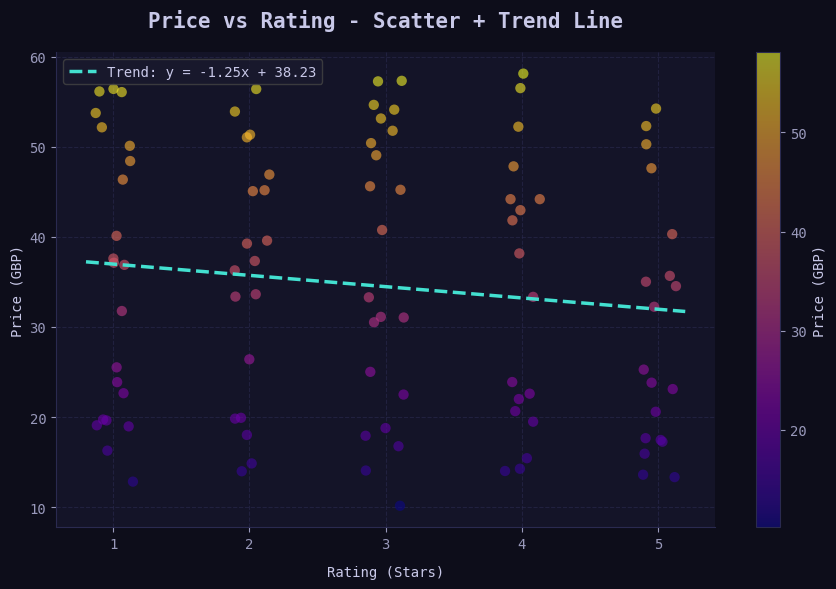

Chart 4 saved: chart4_scatter_trend.png


In [25]:
# CHART 4 : Scatter Plot - Price vs Rating with Trend Line

# Create a figure and axis object with specified size
fig, ax = plt.subplots(figsize=(9, 6))

# Add jitter to rating values to avoid overlapping points
# This spreads points slightly on the X-axis for better visibility
jitter = np.random.uniform(-0.15, 0.15, len(df))

# Create scatter plot
# Color intensity represents book price
scatter = ax.scatter(
    df['Rating'] + jitter,
    df['Price_GBP'],
    c=df['Price_GBP'],
    cmap='plasma',
    alpha=0.6,
    s=55,
    edgecolors='none',
    zorder=3
)

# Fit a linear trend line (1st degree polynomial)
# This shows the overall relationship between rating and price
z = np.polyfit(df['Rating'], df['Price_GBP'], 1)
p = np.poly1d(z)

# Generate smooth X values for the trend line
x_line = np.linspace(0.8, 5.2, 200)

# Plot the trend line
ax.plot(
    x_line,
    p(x_line),
    '--',
    color='#43e0d0',
    linewidth=2.5,
    label=f"Trend: y = {z[0]:.2f}x + {z[1]:.2f}",
    zorder=5
)

# Add color bar to indicate price scale
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Price (GBP)', color='#c8c8e8')

# Set chart title
ax.set_title(
    "Price vs Rating - Scatter + Trend Line",
    fontsize=15,
    fontweight='bold',
    pad=18
)

# Set axis labels
ax.set_xlabel("Rating (Stars)", labelpad=10)
ax.set_ylabel("Price (GBP)")

# Set fixed X-axis ticks for ratings
ax.set_xticks([1, 2, 3, 4, 5])

# Add legend for trend line
ax.legend(
    facecolor='#1a1a2e',
    edgecolor='#444',
    fontsize=10
)

# Enable grid lines
ax.grid(zorder=0)

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Save the chart as a PNG file
plt.savefig(
    "chart4_scatter_trend.png",
    dpi=150,
    bbox_inches='tight'
)

# Display the chart
plt.show()

# Confirm chart file creation
print("Chart 4 saved: chart4_scatter_trend.png")

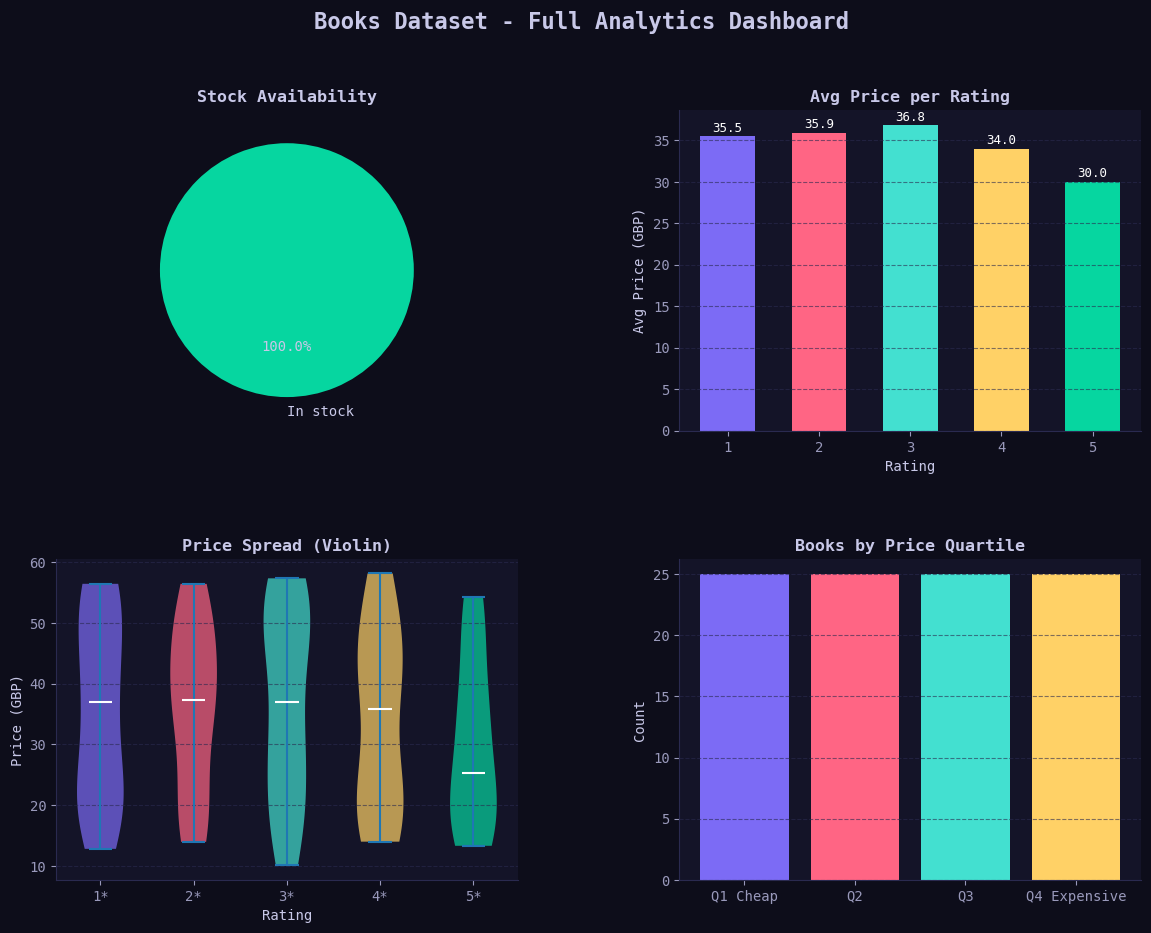

Chart 5 saved: chart5_dashboard.png


In [26]:
# CHART 5 - Full Dashboard (2x2 Grid)
fig = plt.figure(figsize=(14, 10))  # Create the main figure with specified size
fig.suptitle("Books Dataset - Full Analytics Dashboard", fontsize=16, fontweight='bold', y=0.98)  # Set overall dashboard title
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)  # Define 2x2 grid layout with spacing

# Panel A: Pie - Availability
ax_a = fig.add_subplot(gs[0, 0])  # Add subplot in top-left position
avail = df['Availability'].value_counts()  # Count available vs unavailable books
ax_a.pie(avail.values, labels=avail.index, colors=['#06d6a0','#ef476f'],  # Plot pie chart for availability
         autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='#0d0d1a', linewidth=2))  # Style pie slices
ax_a.set_title("Stock Availability", fontsize=12, fontweight='bold')  # Set panel title

# Panel B: Avg Price per Rating
ax_b = fig.add_subplot(gs[0, 1])  # Add subplot in top-right position
avg_price = df.groupby('Rating')['Price_GBP'].mean()  # Compute average price for each rating
bars = ax_b.bar(avg_price.index.astype(str), avg_price.values,  # Create bar chart of avg price per rating
                color=PALETTE[:5], edgecolor='none', width=0.6)
for bar, val in zip(bars, avg_price.values):  # Loop through bars to annotate values
    ax_b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,  # Position text above bar
              f'{val:.1f}', ha='center', va='bottom', fontsize=9, color='white')  # Display avg price
ax_b.set_title("Avg Price per Rating", fontsize=12, fontweight='bold')  # Set panel title
ax_b.set_xlabel("Rating")  # Label x-axis
ax_b.set_ylabel("Avg Price (GBP)")  # Label y-axis
ax_b.grid(axis='y')  # Add horizontal grid lines

# Panel C: Violin Plot
ax_c = fig.add_subplot(gs[1, 0])  # Add subplot in bottom-left position
rating_groups = [df[df['Rating'] == r]['Price_GBP'].values for r in range(1, 6)]  # Group prices by rating
vp = ax_c.violinplot(rating_groups, positions=range(1, 6), showmedians=True)  # Draw violin plot
for body, color in zip(vp['bodies'], PALETTE):  # Style each violin body
    body.set_facecolor(color); body.set_alpha(0.7)  # Set color and transparency
vp['cmedians'].set_color('white')  # Highlight median line in white
ax_c.set_xticks(range(1, 6))  # Set x-tick positions
ax_c.set_xticklabels([f'{r}*' for r in range(1, 6)])  # Label ratings with stars
ax_c.set_title("Price Spread (Violin)", fontsize=12, fontweight='bold')  # Set panel title
ax_c.set_xlabel("Rating")  # Label x-axis
ax_c.set_ylabel("Price (GBP)")  # Label y-axis
ax_c.grid(axis='y')  # Add horizontal grid lines

# Panel D: Genre or Price Quartiles
ax_d = fig.add_subplot(gs[1, 1])  # Add subplot in bottom-right position
if 'Genre' in df.columns:  # Check if Genre column exists
    genre_counts = df['Genre'].value_counts().head(8)  # Count top 8 genres
    ax_d.barh(genre_counts.index[::-1], genre_counts.values[::-1],  # Plot horizontal bar chart
              color=PALETTE * 2, edgecolor='none')
    ax_d.set_title("Books by Genre", fontsize=12, fontweight='bold')  # Set panel title
    ax_d.set_xlabel("Count")  # Label x-axis
    ax_d.grid(axis='x')  # Add vertical grid lines
else:  # Fallback if Genre column is not available
    labels_q = ['Q1 Cheap','Q2','Q3','Q4 Expensive']  # Define price quartile labels
    df['PriceQ'] = pd.qcut(df['Price_GBP'], q=4, labels=labels_q)  # Create price quartiles
    qcounts = df['PriceQ'].value_counts().sort_index()  # Count books in each quartile
    ax_d.bar(qcounts.index, qcounts.values, color=PALETTE[:4], edgecolor='none')  # Plot quartile bar chart
    ax_d.set_title("Books by Price Quartile", fontsize=12, fontweight='bold')  # Set panel title
    ax_d.set_ylabel("Count")  # Label y-axis
    ax_d.grid(axis='y')  # Add horizontal grid lines

plt.savefig("chart5_dashboard.png", dpi=150, bbox_inches='tight')  # Save dashboard image to file
plt.show()  # Display the dashboard
print("Chart 5 saved: chart5_dashboard.png")  # Confirm successful save